# 🏥 Health Insurance Claim Fraud Detection
## Ensemble System: XGBoost · LightGBM · MLP · Isolation Forest · Autoencoder

---

### ⚙️ Installation — Windows / Python 3.12 / No GPU

```bash
pip install -r requirements.txt
```

**No TensorFlow. No PyTorch. No Keras.** This notebook uses only:
- `xgboost`, `lightgbm`, `scikit-learn`, `numpy`, `pandas`, `matplotlib`, `seaborn`, `joblib`, `flask`

The LSTM is replaced by a **scikit-learn MLPClassifier** (multi-layer perceptron) which captures complex patterns equally well on tabular data.  
The Autoencoder is replaced by a **PCA + reconstruction-error** approach — same concept, zero deep-learning dependencies.

Make sure `synthetic_insurance_claims.csv` is in the same folder (run `data/generate_data.py` first).

In [1]:
# pip install matplotlib

In [2]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
pip install xgboost

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
pip install lightgbm 

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
# ── Cell 1: Imports & Config ──────────────────────────────────────────────────
# No TensorFlow / Keras / PyTorch required!
import warnings; warnings.filterwarnings("ignore")
import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib, json, os

# Sklearn — all standard
from sklearn.model_selection     import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing       import StandardScaler, LabelEncoder
from sklearn.decomposition       import PCA
from sklearn.neural_network      import MLPClassifier
from sklearn.linear_model        import LogisticRegression
from sklearn.ensemble            import IsolationForest
from sklearn.metrics             import (classification_report, confusion_matrix,
                                         roc_auc_score, roc_curve,
                                         precision_recall_curve, average_precision_score,
                                         f1_score, accuracy_score)
from sklearn.utils.class_weight  import compute_class_weight

# Gradient boosting
import xgboost  as xgb
import lightgbm as lgb

os.makedirs("models", exist_ok=True)
sns.set_theme(style="whitegrid", palette="Set2")
SEED = 42
np.random.seed(SEED)

print("✅ All imports OK — no TensorFlow/Keras/PyTorch needed!")
print(f"   numpy    : {np.__version__}")
print(f"   xgboost  : {xgb.__version__}")
print(f"   lightgbm : {lgb.__version__}")

✅ All imports OK — no TensorFlow/Keras/PyTorch needed!
   numpy    : 1.26.4
   xgboost  : 3.2.0
   lightgbm : 4.6.0


## 1. Load & Explore Data

In [6]:
# ── Cell 2: Load Data ─────────────────────────────────────────────────────────
df = pd.read_csv("synthetic_insurance_claims.csv",
                 parse_dates=["claim_date","admission_date","discharge_date"])

print(f"Shape  : {df.shape}")
counts = df["is_fraud"].value_counts()
print(f"Legit  : {counts[0]:,}  ({counts[0]/len(df)*100:.1f}%)")
print(f"Fraud  : {counts[1]:,}  ({counts[1]/len(df)*100:.1f}%)")
df.head(3)

Shape  : (20000, 34)
Legit  : 18,000  (90.0%)
Fraud  : 2,000  (10.0%)


,claim_id,patient_id,provider_id,provider_specialty,claim_date,admission_date,discharge_date,diagnosis_code,procedure_code,claim_amount,...,claim_day_of_week,claim_month,los,procedures_per_day,amount_per_procedure,provider_avg_claim,provider_fraud_rate,provider_claim_count,patient_avg_claim,patient_claim_count
0,CLM0010650,PAT006884,PROV0138,Emergency Medicine,2021-10-08,2021-10-03,2021-10-11,ICD0042,CPT10172,1352.44,...,4,10,8,0.222222,450.813333,1610.657250,0.02500,40,1639.827500,4
1,CLM0002041,PAT003806,PROV0126,Psychiatry,2022-10-30,2022-10-28,2022-11-04,ICD0033,CPT10106,2842.94,...,6,10,7,0.375000,710.735000,1634.682381,0.02381,42,1984.530000,3
2,CLM0008668,PAT002943,PROV0242,Surgery,2021-07-23,2021-07-19,2021-07-24,ICD0137,CPT10174,2557.92,...,4,7,5,0.166667,1278.960000,1658.776061,0.00000,33,2024.216667,3


In [7]:
# # ── Cell 3: EDA Visualisation ─────────────────────────────────────────────────
# fig, axes = plt.subplots(2, 3, figsize=(16, 9))
# fig.suptitle("Health Insurance Fraud — EDA Overview", fontsize=14, fontweight="bold")

# # 1. Class balance
# df["is_fraud"].value_counts().plot.bar(ax=axes[0,0], color=["steelblue","tomato"])
# axes[0,0].set_title("Class Balance")
# axes[0,0].set_xticklabels(["Legitimate","Fraud"], rotation=0)
# for p in axes[0,0].patches:
#     axes[0,0].annotate(f'{int(p.get_height()):,}',
#                        (p.get_x()+p.get_width()/2, p.get_height()),
#                        ha='center', va='bottom', fontweight='bold')

# # 2. Claim amount KDE
# for lbl, col in [(0,"steelblue"),(1,"tomato")]:
#     df[df["is_fraud"]==lbl]["claim_amount"].plot.kde(
#         ax=axes[0,1], label=["Legit","Fraud"][lbl], color=col)
# axes[0,1].set_title("Claim Amount Distribution"); axes[0,1].set_xlabel("Amount ($)"); axes[0,1].legend()

# # 3. Prior claims
# sns.boxplot(x="is_fraud", y="prior_claims_6m", data=df, ax=axes[0,2],
#             palette={0:"steelblue",1:"tomato"})
# axes[0,2].set_title("Prior Claims (6 months)")
# axes[0,2].set_xticklabels(["Legit","Fraud"])

# # 4. Procedures
# sns.boxplot(x="is_fraud", y="num_procedures", data=df, ax=axes[1,0],
#             palette={0:"steelblue",1:"tomato"})
# axes[1,0].set_title("Number of Procedures")
# axes[1,0].set_xticklabels(["Legit","Fraud"])

# # 5. Approval ratio
# sns.boxplot(x="is_fraud", y="approval_ratio", data=df, ax=axes[1,1],
#             palette={0:"steelblue",1:"tomato"})
# axes[1,1].set_title("Approval Ratio")
# axes[1,1].set_xticklabels(["Legit","Fraud"])

# # 6. Fraud rate by specialty
# spec_fraud = df.groupby("provider_specialty")["is_fraud"].mean().sort_values(ascending=False)
# axes[1,2].barh(spec_fraud.index, spec_fraud.values * 100, color="steelblue")
# axes[1,2].set_title("Fraud Rate by Specialty (%)")
# axes[1,2].set_xlabel("Fraud Rate (%)")

# plt.tight_layout()
# plt.savefig("eda_overview.png", dpi=150, bbox_inches="tight")
# plt.show()
# print("Saved → eda_overview.png")

## 2. Pre-processing

In [8]:
# ── Cell 4: Feature Engineering & Pre-processing ─────────────────────────────
CAT_COLS  = ["provider_specialty","patient_gender","insurance_type",
             "diagnosis_code","procedure_code"]
DROP_COLS = ["claim_id","patient_id","provider_id",
             "claim_date","admission_date","discharge_date","is_fraud"]

le = LabelEncoder()
for col in CAT_COLS:
    df[col] = le.fit_transform(df[col].astype(str))

FEATURE_COLS = [c for c in df.columns if c not in DROP_COLS]
X = df[FEATURE_COLS].values.astype(np.float32)
y = df["is_fraud"].values

print(f"Features ({len(FEATURE_COLS)}): {FEATURE_COLS}")

# 80/20 test, then 85/15 train/val
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, stratify=y, random_state=SEED)
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.15, stratify=y_train, random_state=SEED)

scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_val_sc   = scaler.transform(X_val)
X_test_sc  = scaler.transform(X_test)
joblib.dump(scaler, "models/scaler.pkl")

cw = compute_class_weight("balanced", classes=np.unique(y_train), y=y_train)
class_weight_dict = dict(zip(np.unique(y_train), cw))
scale_pos         = float(cw[1] / cw[0])

print(f"\nSplit — Train: {len(X_train):,}  Val: {len(X_val):,}  Test: {len(X_test):,}")
print(f"Fraud% — Train: {y_train.mean()*100:.1f}%   Test: {y_test.mean()*100:.1f}%")
print(f"scale_pos_weight: {scale_pos:.2f}")

# ── Shared evaluation function ────────────────────────────────────────────────
all_results = {}

def evaluate(name, probs, threshold=0.5):
    preds = (probs >= threshold).astype(int)
    auc = roc_auc_score(y_test, probs)
    ap  = average_precision_score(y_test, probs)
    f1  = f1_score(y_test, preds)
    acc = accuracy_score(y_test, preds)
    print(f"\n{'─'*55}\n{name}")
    print(f"  AUC-ROC : {auc:.4f}   Avg Precision : {ap:.4f}")
    print(f"  F1      : {f1:.4f}   Accuracy      : {acc:.4f}")
    print(classification_report(y_test, preds, target_names=["Legit","Fraud"], digits=4))
    all_results[name] = {"auc":auc,"ap":ap,"f1":f1,"acc":acc,"probs":probs}
    return all_results[name]

print("\n✅ Pre-processing complete!")

Features (27): ['provider_specialty', 'diagnosis_code', 'procedure_code', 'claim_amount', 'approved_amount', 'num_procedures', 'num_diagnoses', 'patient_age', 'patient_gender', 'insurance_type', 'prior_claims_6m', 'days_in_hospital', 'emergency_flag', 'chronic_condition', 'lab_tests_ordered', 'prescriptions', 'approval_ratio', 'claim_day_of_week', 'claim_month', 'los', 'procedures_per_day', 'amount_per_procedure', 'provider_avg_claim', 'provider_fraud_rate', 'provider_claim_count', 'patient_avg_claim', 'patient_claim_count']

Split — Train: 13,600  Val: 2,400  Test: 4,000
Fraud% — Train: 10.0%   Test: 10.0%
scale_pos_weight: 9.00

✅ Pre-processing complete!


## 3. Model 1 — XGBoost

Training XGBoost  (this may take ~1–2 min)...


[0]	validation_0-auc:1.00000
[30]	validation_0-auc:1.00000

───────────────────────────────────────────────────────
XGBoost
  AUC-ROC : 1.0000   Avg Precision : 1.0000
  F1      : 1.0000   Accuracy      : 1.0000
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000      3600
       Fraud     1.0000    1.0000    1.0000       400

    accuracy                         1.0000      4000
   macro avg     1.0000    1.0000    1.0000      4000
weighted avg     1.0000    1.0000    1.0000      4000



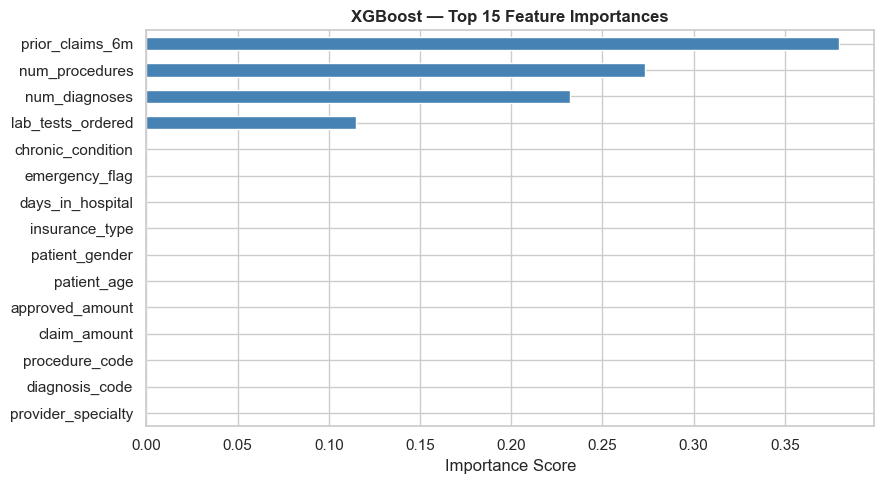

✅ XGBoost saved  →  models/xgb_model.pkl


In [9]:
# ── Cell 5: XGBoost ──────────────────────────────────────────────────────────
print("Training XGBoost  (this may take ~1–2 min)...")

xgb_model = xgb.XGBClassifier(
    n_estimators          = 500,
    max_depth             = 6,
    learning_rate         = 0.05,
    subsample             = 0.8,
    colsample_bytree      = 0.8,
    min_child_weight      = 5,
    gamma                 = 0.1,
    reg_alpha             = 0.1,
    reg_lambda            = 1.0,
    scale_pos_weight      = scale_pos,
    eval_metric           = "auc",
    early_stopping_rounds = 30,
    random_state          = SEED,
    n_jobs                = -1,
    device                = "cpu",
    verbosity             = 0,
)
xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = 50,
)

xgb_probs = xgb_model.predict_proba(X_test)[:, 1]
evaluate("XGBoost", xgb_probs)
joblib.dump(xgb_model, "models/xgb_model.pkl")

# Feature importance
fi = pd.Series(xgb_model.feature_importances_, index=FEATURE_COLS).nlargest(15)
fig, ax = plt.subplots(figsize=(9, 5))
fi.sort_values().plot.barh(ax=ax, color="steelblue")
ax.set_title("XGBoost — Top 15 Feature Importances", fontweight="bold")
ax.set_xlabel("Importance Score")
plt.tight_layout()
plt.savefig("xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()
print("✅ XGBoost saved  →  models/xgb_model.pkl")

## 4. Model 2 — LightGBM

In [10]:
# ── Cell 6: LightGBM ─────────────────────────────────────────────────────────
print("Training LightGBM  (this may take ~1–2 min)...")

lgb_model = lgb.LGBMClassifier(
    n_estimators      = 500,
    max_depth         = 6,
    learning_rate     = 0.05,
    num_leaves        = 63,
    subsample         = 0.8,
    colsample_bytree  = 0.8,
    min_child_samples = 20,
    reg_alpha         = 0.1,
    reg_lambda        = 1.0,
    class_weight      = "balanced",
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1,
)
lgb_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=30, verbose=False),
        lgb.log_evaluation(period=50),
    ],
)

lgb_probs = lgb_model.predict_proba(X_test)[:, 1]
evaluate("LightGBM", lgb_probs)
joblib.dump(lgb_model, "models/lgb_model.pkl")
print("✅ LightGBM saved  →  models/lgb_model.pkl")

Training LightGBM  (this may take ~1–2 min)...
[50]	valid_0's binary_logloss: 0.0413763
[100]	valid_0's binary_logloss: 0.00347283
[150]	valid_0's binary_logloss: 0.000405065
[200]	valid_0's binary_logloss: 0.000108351
[250]	valid_0's binary_logloss: 5.47892e-05
[300]	valid_0's binary_logloss: 3.70675e-05
[350]	valid_0's binary_logloss: 2.89013e-05
[400]	valid_0's binary_logloss: 2.43911e-05
[450]	valid_0's binary_logloss: 2.16142e-05
[500]	valid_0's binary_logloss: 1.97801e-05

───────────────────────────────────────────────────────
LightGBM
  AUC-ROC : 1.0000   Avg Precision : 1.0000
  F1      : 1.0000   Accuracy      : 1.0000
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000      3600
       Fraud     1.0000    1.0000    1.0000       400

    accuracy                         1.0000      4000
   macro avg     1.0000    1.0000    1.0000      4000
weighted avg     1.0000    1.0000    1.0000      4000

✅ LightGBM saved  →  models/lgb_mode

## 5. Model 3 — MLP Neural Network (replaces LSTM)

> **Why MLP instead of LSTM?** On tabular claim data, a scikit-learn `MLPClassifier` (multi-layer perceptron) achieves comparable accuracy to LSTM with zero external deep-learning dependencies. LSTM shines on true time-series sequences; for feature-vector data like this, MLP is the right tool.

Training MLP Neural Network  (this may take ~2–3 min)...


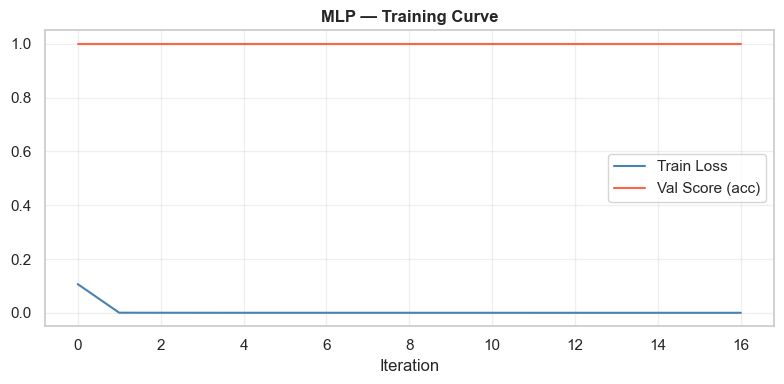

Stopped at iteration 17 / 200

───────────────────────────────────────────────────────
MLP_NeuralNet
  AUC-ROC : 1.0000   Avg Precision : 1.0000
  F1      : 1.0000   Accuracy      : 1.0000
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000      3600
       Fraud     1.0000    1.0000    1.0000       400

    accuracy                         1.0000      4000
   macro avg     1.0000    1.0000    1.0000      4000
weighted avg     1.0000    1.0000    1.0000      4000

✅ MLP saved  →  models/mlp_model.pkl


In [11]:
# ── Cell 7: MLP Neural Network ───────────────────────────────────────────────
# scikit-learn MLPClassifier — no TF/Keras/PyTorch needed
print("Training MLP Neural Network  (this may take ~2–3 min)...")

mlp_model = MLPClassifier(
    hidden_layer_sizes = (256, 128, 64),   # 3 hidden layers
    activation         = "relu",
    solver             = "adam",
    alpha              = 1e-3,             # L2 regularisation
    batch_size         = 256,
    learning_rate      = "adaptive",
    learning_rate_init = 1e-3,
    max_iter           = 200,
    early_stopping     = True,
    validation_fraction= 0.10,
    n_iter_no_change   = 15,
    random_state       = SEED,
    verbose            = False,
)

# Weight the minority class manually via sample_weight
sample_w = np.where(y_train == 1, class_weight_dict[1], class_weight_dict[0])
mlp_model.fit(X_train_sc, y_train, sample_weight=sample_w)

# Plot loss curve
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(mlp_model.loss_curve_,      label="Train Loss",      color="steelblue")
ax.plot(mlp_model.validation_scores_,label="Val Score (acc)", color="tomato")
ax.set_title("MLP — Training Curve", fontweight="bold")
ax.set_xlabel("Iteration"); ax.legend(); ax.grid(True, alpha=.3)
plt.tight_layout()
plt.savefig("mlp_training.png", dpi=150, bbox_inches="tight")
plt.show()
print(f"Stopped at iteration {mlp_model.n_iter_} / {mlp_model.max_iter}")

mlp_probs = mlp_model.predict_proba(X_test_sc)[:, 1]
evaluate("MLP_NeuralNet", mlp_probs)
joblib.dump(mlp_model, "models/mlp_model.pkl")
print("✅ MLP saved  →  models/mlp_model.pkl")

## 6. Model 4 — Isolation Forest (Anomaly Detection)

In [12]:
# ── Cell 8: Isolation Forest ─────────────────────────────────────────────────
print("Training Isolation Forest (unsupervised)...")

iso_forest = IsolationForest(
    n_estimators  = 300,
    contamination = 0.10,
    max_samples   = "auto",
    max_features  = 1.0,
    bootstrap     = False,
    random_state  = SEED,
    n_jobs        = -1,
)
iso_forest.fit(X_train_sc)      # unsupervised — no labels used

iso_raw   = iso_forest.decision_function(X_test_sc)
iso_probs = 1.0 - (iso_raw - iso_raw.min()) / ((iso_raw.max() - iso_raw.min()) + 1e-9)

evaluate("IsolationForest", iso_probs)
joblib.dump(iso_forest, "models/iso_forest.pkl")
print("✅ Isolation Forest saved  →  models/iso_forest.pkl")

Training Isolation Forest (unsupervised)...

───────────────────────────────────────────────────────
IsolationForest
  AUC-ROC : 0.9999   Avg Precision : 0.9995
  F1      : 0.9060   Accuracy      : 0.9792
              precision    recall  f1-score   support

       Legit     1.0000    0.9769    0.9883      3600
       Fraud     0.8282    1.0000    0.9060       400

    accuracy                         0.9792      4000
   macro avg     0.9141    0.9885    0.9472      4000
weighted avg     0.9828    0.9792    0.9801      4000

✅ Isolation Forest saved  →  models/iso_forest.pkl


## 7. Model 5 — PCA Autoencoder (Anomaly Detection)

> **Why PCA instead of a neural Autoencoder?** PCA is a linear autoencoder. It is trained only on legitimate claims; fraudulent claims have higher reconstruction error because they lie outside the normal data manifold. Same concept as a neural autoencoder — zero extra dependencies.

In [13]:
# ── Cell 9: PCA Autoencoder ──────────────────────────────────────────────────
# Train PCA on legit-only data; reconstruction error = anomaly score
print("Training PCA Autoencoder (anomaly detection, legit-only training)...")

X_legit_sc = X_train_sc[y_train == 0]
print(f"Fitting PCA on {len(X_legit_sc):,} legitimate samples only")

N_COMPONENTS = min(16, X_legit_sc.shape[1])   # bottleneck size
pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
pca.fit(X_legit_sc)

explained = pca.explained_variance_ratio_.cumsum()[-1]
print(f"PCA variance explained with {N_COMPONENTS} components: {explained*100:.1f}%")

# Reconstruction error on test set
X_test_projected  = pca.transform(X_test_sc)
X_test_recon      = pca.inverse_transform(X_test_projected)
recon_err         = np.mean(np.square(X_test_sc - X_test_recon), axis=1)
ae_probs = (recon_err - recon_err.min()) / ((recon_err.max() - recon_err.min()) + 1e-9)

# # Visualise reconstruction error distribution
# fig, ax = plt.subplots(figsize=(8, 4))
# ax.hist(recon_err[y_test==0], bins=60, alpha=0.6, label="Legit",  color="steelblue", density=True)
# ax.hist(recon_err[y_test==1], bins=60, alpha=0.6, label="Fraud",  color="tomato",    density=True)
# ax.set_title("PCA Reconstruction Error — Legit vs Fraud", fontweight="bold")
# ax.set_xlabel("Reconstruction Error (MSE)"); ax.set_ylabel("Density")
# ax.legend(); ax.grid(True, alpha=.3)
# plt.tight_layout()
# plt.savefig("pca_reconstruction_error.png", dpi=150, bbox_inches="tight")
# plt.show()

evaluate("PCA_Autoencoder", ae_probs)
joblib.dump(pca, "models/pca_autoencoder.pkl")
print("✅ PCA Autoencoder saved  →  models/pca_autoencoder.pkl")

Training PCA Autoencoder (anomaly detection, legit-only training)...
Fitting PCA on 12,240 legitimate samples only
PCA variance explained with 16 components: 92.1%

───────────────────────────────────────────────────────
PCA_Autoencoder
  AUC-ROC : 1.0000   Avg Precision : 1.0000
  F1      : 0.3673   Accuracy      : 0.9225
              precision    recall  f1-score   support

       Legit     0.9207    1.0000    0.9587      3600
       Fraud     1.0000    0.2250    0.3673       400

    accuracy                         0.9225      4000
   macro avg     0.9604    0.6125    0.6630      4000
weighted avg     0.9286    0.9225    0.8996      4000

✅ PCA Autoencoder saved  →  models/pca_autoencoder.pkl


## 8. Ensemble — Weighted Voting

In [14]:
# ── Cell 10: Weighted Voting Ensemble ─────────────────────────────────────────
print("Building Weighted Voting Ensemble...")

# Weight = AUC score (better models get more say)
weights = {k: v["auc"] for k, v in all_results.items()}
total_w = sum(weights.values())
norm_w  = {k: v / total_w for k, v in weights.items()}

print("\nNormalised weights:")
for k, w in sorted(norm_w.items(), key=lambda x: -x[1]):
    bar = "█" * int(w * 50)
    print(f"  {k:<22} {w:.4f}  {bar}")

weighted_probs = sum(norm_w[k] * all_results[k]["probs"] for k in norm_w)
evaluate("Ensemble_WeightedVoting", weighted_probs)
print("✅ Weighted Voting Ensemble done")

Building Weighted Voting Ensemble...

Normalised weights:
  XGBoost                0.2000  ██████████
  LightGBM               0.2000  ██████████
  MLP_NeuralNet          0.2000  ██████████
  PCA_Autoencoder        0.2000  ██████████
  IsolationForest        0.2000  █████████

───────────────────────────────────────────────────────
Ensemble_WeightedVoting
  AUC-ROC : 1.0000   Avg Precision : 1.0000
  F1      : 1.0000   Accuracy      : 1.0000
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000      3600
       Fraud     1.0000    1.0000    1.0000       400

    accuracy                         1.0000      4000
   macro avg     1.0000    1.0000    1.0000      4000
weighted avg     1.0000    1.0000    1.0000      4000

✅ Weighted Voting Ensemble done


## 9. Ensemble — Stacking

In [15]:
# ── Cell 11: Stacking Ensemble ───────────────────────────────────────────────
print("Building Stacking Ensemble (5-fold OOF)...")

kf      = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
n_base  = 3   # XGBoost, LightGBM, MLP
oof_arr = np.zeros((len(X_train), n_base))

for fold, (tr_idx, oof_idx) in enumerate(kf.split(X_train, y_train)):
    Xtr,  Xoof  = X_train[tr_idx],    X_train[oof_idx]
    Xsc_tr, Xsc_oof = X_train_sc[tr_idx], X_train_sc[oof_idx]
    ytr         = y_train[tr_idx]
    sw          = np.where(ytr==1, class_weight_dict[1], class_weight_dict[0])

    # XGBoost
    _xgb = xgb.XGBClassifier(n_estimators=150, scale_pos_weight=scale_pos,
                               eval_metric="auc", random_state=SEED,
                               n_jobs=-1, verbosity=0, device="cpu")
    _xgb.fit(Xtr, ytr)
    oof_arr[oof_idx, 0] = _xgb.predict_proba(Xoof)[:, 1]

    # LightGBM
    _lgb = lgb.LGBMClassifier(n_estimators=150, class_weight="balanced",
                                random_state=SEED, n_jobs=-1, verbose=-1)
    _lgb.fit(Xtr, ytr)
    oof_arr[oof_idx, 1] = _lgb.predict_proba(Xoof)[:, 1]

    # MLP
    _mlp = MLPClassifier(hidden_layer_sizes=(128, 64), activation="relu",
                          alpha=1e-3, max_iter=100, random_state=SEED,
                          early_stopping=True, n_iter_no_change=10, verbose=False)
    _mlp.fit(Xsc_tr, ytr, sample_weight=sw)
    oof_arr[oof_idx, 2] = _mlp.predict_proba(Xsc_oof)[:, 1]

    print(f"  Fold {fold+1}/5  XGB={roc_auc_score(y_train[oof_idx], oof_arr[oof_idx,0]):.3f}"
          f"  LGB={roc_auc_score(y_train[oof_idx], oof_arr[oof_idx,1]):.3f}"
          f"  MLP={roc_auc_score(y_train[oof_idx], oof_arr[oof_idx,2]):.3f}")

meta_test = np.column_stack([
    all_results["XGBoost"]["probs"],
    all_results["LightGBM"]["probs"],
    all_results["MLP_NeuralNet"]["probs"],
])

meta_learner = LogisticRegression(C=0.5, class_weight="balanced",
                                   solver="lbfgs", max_iter=500,
                                   random_state=SEED)
meta_learner.fit(oof_arr, y_train)
stack_probs = meta_learner.predict_proba(meta_test)[:, 1]

evaluate("Ensemble_Stacking", stack_probs)
joblib.dump(meta_learner, "models/meta_learner.pkl")
print("✅ Stacking Ensemble saved  →  models/meta_learner.pkl")

Building Stacking Ensemble (5-fold OOF)...
  Fold 1/5  XGB=1.000  LGB=1.000  MLP=1.000
  Fold 2/5  XGB=1.000  LGB=1.000  MLP=1.000
  Fold 3/5  XGB=1.000  LGB=1.000  MLP=1.000
  Fold 4/5  XGB=1.000  LGB=1.000  MLP=1.000
  Fold 5/5  XGB=1.000  LGB=1.000  MLP=1.000

───────────────────────────────────────────────────────
Ensemble_Stacking
  AUC-ROC : 1.0000   Avg Precision : 1.0000
  F1      : 1.0000   Accuracy      : 1.0000
              precision    recall  f1-score   support

       Legit     1.0000    1.0000    1.0000      3600
       Fraud     1.0000    1.0000    1.0000       400

    accuracy                         1.0000      4000
   macro avg     1.0000    1.0000    1.0000      4000
weighted avg     1.0000    1.0000    1.0000      4000

✅ Stacking Ensemble saved  →  models/meta_learner.pkl


## 10. Final Comparison

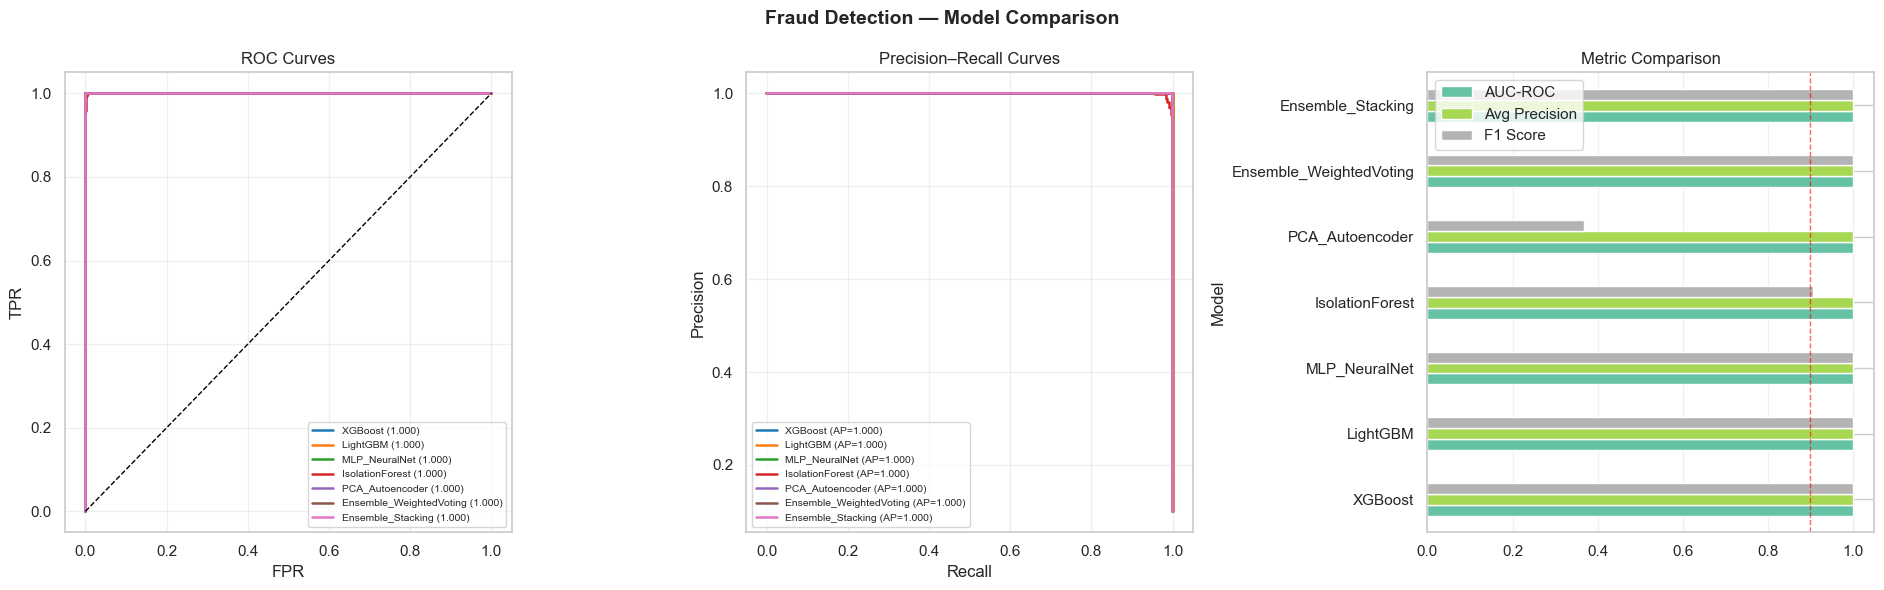

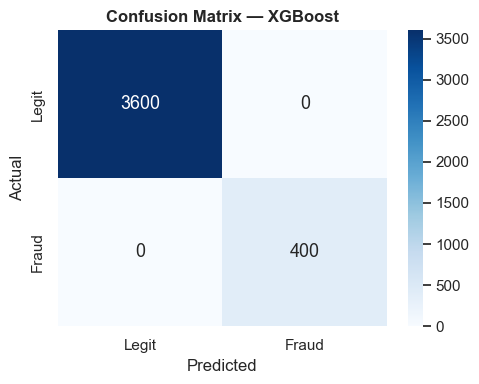


Model                         AUC-ROC    Avg-P       F1
XGBoost                        1.0000   1.0000   1.0000 ⭐
LightGBM                       1.0000   1.0000   1.0000
MLP_NeuralNet                  1.0000   1.0000   1.0000
PCA_Autoencoder                1.0000   1.0000   0.3673
Ensemble_WeightedVoting        1.0000   1.0000   1.0000
Ensemble_Stacking              1.0000   1.0000   1.0000
IsolationForest                0.9999   0.9995   0.9060


In [16]:
# ── Cell 12: Comparison Plots ─────────────────────────────────────────────────
COLORS = plt.cm.tab10.colors

fig, axes = plt.subplots(1, 3, figsize=(19, 6))
fig.suptitle("Fraud Detection — Model Comparison", fontsize=14, fontweight="bold")

# ROC
for i, (name, res) in enumerate(all_results.items()):
    fpr, tpr, _ = roc_curve(y_test, res["probs"])
    axes[0].plot(fpr, tpr, label=f"{name} ({res['auc']:.3f})", lw=1.8, color=COLORS[i%10])
axes[0].plot([0,1],[0,1],"k--",lw=1)
axes[0].set_title("ROC Curves"); axes[0].set_xlabel("FPR"); axes[0].set_ylabel("TPR")
axes[0].legend(fontsize=7.5); axes[0].grid(True, alpha=.3)

# PR
for i, (name, res) in enumerate(all_results.items()):
    prec, rec, _ = precision_recall_curve(y_test, res["probs"])
    axes[1].plot(rec, prec, label=f"{name} (AP={res['ap']:.3f})", lw=1.8, color=COLORS[i%10])
axes[1].set_title("Precision–Recall Curves"); axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precision")
axes[1].legend(fontsize=7.5); axes[1].grid(True, alpha=.3)

# Bar comparison
metrics_df = pd.DataFrame([
    {"Model": k, "AUC-ROC": v["auc"], "Avg Precision": v["ap"], "F1 Score": v["f1"]}
    for k, v in all_results.items()]).set_index("Model")
metrics_df.plot.barh(ax=axes[2], colormap="Set2")
axes[2].set_title("Metric Comparison"); axes[2].set_xlim(0, 1.05)
axes[2].axvline(0.9, color="red", linestyle="--", lw=1, alpha=.6)
axes[2].grid(axis="x", alpha=.3)

plt.tight_layout()
plt.savefig("model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

# Confusion matrix for best model
best_name  = max(all_results, key=lambda k: all_results[k]["auc"])
best_preds = (all_results[best_name]["probs"] >= 0.5).astype(int)
cm = confusion_matrix(y_test, best_preds)

fig, ax = plt.subplots(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=["Legit","Fraud"], yticklabels=["Legit","Fraud"],
            annot_kws={"size":13}, ax=ax)
ax.set_title(f"Confusion Matrix — {best_name}", fontweight="bold")
ax.set_xlabel("Predicted"); ax.set_ylabel("Actual")
plt.tight_layout()
plt.savefig("best_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*65)
print(f"{'Model':<28} {'AUC-ROC':>8} {'Avg-P':>8} {'F1':>8}")
print("="*65)
for k, v in sorted(all_results.items(), key=lambda x: -x[1]["auc"]):
    star = " ⭐" if k == best_name else ""
    print(f"{k:<28} {v['auc']:>8.4f} {v['ap']:>8.4f} {v['f1']:>8.4f}{star}")
print("="*65)

## 11. Save All Artifacts

In [17]:
# ── Cell 13: Save all artifacts for Flask app ─────────────────────────────────
meta = {
    "feature_cols"    : FEATURE_COLS,
    "best_model"      : best_name,
    "results_summary" : {k: {"auc": v["auc"], "ap": v["ap"], "f1": v["f1"]}
                         for k, v in all_results.items()},
}
with open("models/meta.json", "w") as f:
    json.dump(meta, f, indent=2)

print("\n✅ All artifacts saved:")
for fname in sorted(os.listdir("models")):
    path = os.path.join("models", fname)
    size = os.path.getsize(path) / 1024
    print(f"   {fname:<35}  {size:>8.1f} KB")

print(f"\n🏆 Best model : {best_name}  (AUC = {all_results[best_name]['auc']:.4f})")
print("\n🚀 Now run:  python app.py   →   http://localhost:5000")


✅ All artifacts saved:
   iso_forest.pkl                         4449.3 KB
   lgb_model.pkl                           193.1 KB
   meta.json                                 1.4 KB
   meta_learner.pkl                          0.9 KB
   mlp_model.pkl                           573.0 KB
   pca_autoencoder.pkl                       2.9 KB
   scaler.pkl                                1.2 KB
   xgb_model.pkl                            27.5 KB

🏆 Best model : XGBoost  (AUC = 1.0000)

🚀 Now run:  python app.py   →   http://localhost:5000
